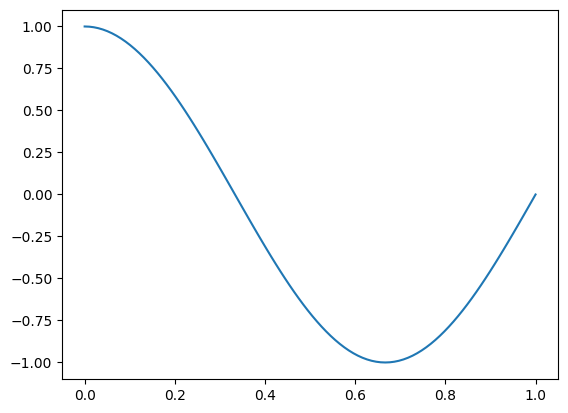

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def true_fun(X):
    return np.cos(1.5 * np.pi * X)
plt.plot(np.linspace(0, 1, 100), true_fun(np.linspace(0, 1, 100)))
plt.show()

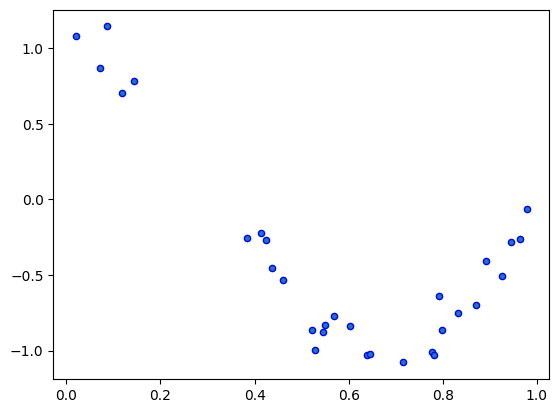

In [3]:
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1
plt.scatter(X, y, edgecolor='b', s=20)
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

X_vis = np.linspace(0, 1, 100)

# **Tarea:Ajuste de Modelos **


### **1. Como primera actividad de la tarea deberás dividir el conjunto de datos en subconjuntos de entrenamiento y prueba, utilizando la función train_test_split de sklearn, con una proporción adecuada para cada uno, dado el tamaño del conjunto de datos.**




En este punto, hemos dividido nuestro conjunto de datos en dos partes: el 67% para el conjunto de entrenamiento y el 33% para el conjunto de validación. Esta división sigue una estrategia estándar y recomendada para asegurar que los modelos que entrenemos generalicen correctamente a datos no vistos, lo que es fundamental en cualquier problema de predicción, especialmente en nuestro ejercicio de ajuste de modelos polinomiales a datos ruidosos.

En nuestro caso, donde estamos intentando ajustar una función sinusoidal, el uso de validación es crucial porque estamos probando varios modelos con diferentes grados de complejidad polinómica. Si no reservamos un conjunto de validación, no tendríamos una manera clara de saber cuál modelo generaliza mejor a datos no vistos.

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

n_samples = 100

X = np.sort(np.random.rand(n_samples)).reshape(-1, 1)
y = true_fun(X).ravel() + np.random.randn(n_samples) * 0.1

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42)

print(f'Tamaño total de la muestra: {len(X)}')
print(f'Tamaño del conjunto de entrenamiento: {len(X_train)}')
print(f'Tamaño del conjunto de validación: {len(X_val)}')


Tamaño total de la muestra: 100
Tamaño del conjunto de entrenamiento: 67
Tamaño del conjunto de validación: 33


### **2. Entrena modelos de regresión lineal sobre el conjunto de entrenamiento generado, utilizando PolynomialFeatures con grados entre 1 y 30, para transformar las características de entrada de cada modelo y así modificar la complejidad de estos.**


    Grado del Polinomio  Error de Entrenamiento  Error de Prueba
0                     1                0.210482         0.219366
1                     2                0.206665         0.231399
2                     3                0.013168         0.016768
3                     4                0.013146         0.016799
4                     5                0.010041         0.008633
5                     6                0.010039         0.008704
6                     7                0.010039         0.008723
7                     8                0.009880         0.008433
8                     9                0.009866         0.008037
9                    10                0.009864         0.008074
10                   11                0.009807         0.008204
11                   12                0.009807         0.008248
12                   13                0.009736         0.011828
13                   14                0.009736         0.010921
14                   15  

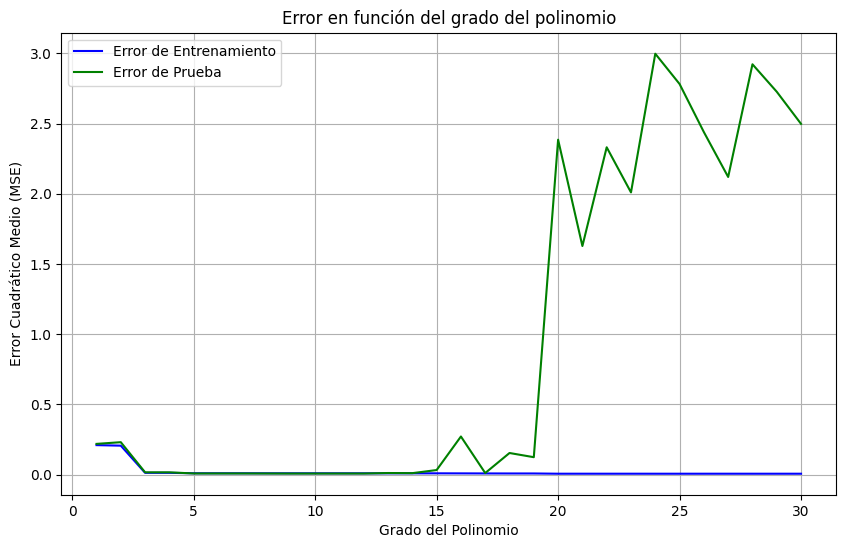

In [25]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

def entrenar_modelos_polinomiales(X_train, y_train, X_test, y_test, max_grado):

    degrees = []
    train_errors = []
    test_errors = []

    for degree in range(1, max_grado + 1):
        poly_features = PolynomialFeatures(degree=degree)

        X_train_poly = poly_features.fit_transform(X_train)
        X_test_poly = poly_features.transform(X_test)

        model = LinearRegression()

        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        train_error = mean_squared_error(y_train, y_train_pred)
        test_error = mean_squared_error(y_test, y_test_pred)

        degrees.append(degree)
        train_errors.append(train_error)
        test_errors.append(test_error)

    results_df = pd.DataFrame({
        'Grado del Polinomio': degrees,
        'Error de Entrenamiento': train_errors,
        'Error de Prueba': test_errors
    })


    return results_df


tabla_errores = entrenar_modelos_polinomiales(X_train, y_train, X_test, y_test, 30)

print(tabla_errores)


plt.figure(figsize=(10, 6))
plt.plot(tabla_errores['Grado del Polinomio'], tabla_errores['Error de Entrenamiento'], label='Error de Entrenamiento',color='blue')
plt.plot(tabla_errores['Grado del Polinomio'], tabla_errores['Error de Prueba'], label='Error de Prueba',color='green')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Error en función del grado del polinomio')
plt.legend()
plt.grid(True)
plt.show()


En el análisis de los resultados, observamos que para grados polinomiales bajos (1 a 10), tanto el error de entrenamiento como el error de prueba se mantienen bajos, lo que sugiere un ajuste adecuado del modelo. Estos grados logran capturar correctamente la tendencia general de los datos sin sobreajustar. Sin embargo, a partir del grado 15, el error de prueba comienza a aumentar considerablemente, mientras que el error de entrenamiento permanece bajo, lo que indica un claro sobreajuste. Esto ocurre porque el modelo se adapta demasiado a los datos de entrenamiento, incluyendo el ruido, lo que afecta negativamente su capacidad para generalizar en datos nuevos. En conclusión, los modelos con grados intermedios, entre 3 y 10, proporcionan el mejor equilibrio entre complejidad y generalización, mientras que los grados más altos muestran un sobreajuste significativo.


**3. Utilizando el conjunto de prueba, busca dentro de los modelos entrenados uno que presente subajuste, otro con sobreajuste y finalmente uno con ajuste adecuado. Identifique claramente cuál fue el grado utilizado por PolynomialFeatures para cada uno.**




In [26]:
# Definir grados representativos para subajuste, ajuste adecuado y sobreajuste
grado_subajuste = 1   # Un grado bajo
grado_ajuste_adecuado = 5  # Un grado intermedio con bajo error en ambos conjuntos
grado_sobrecarga = 20  # Un grado alto con sobreajuste evidente

# Visualización de los errores para estos grados en particular
print("Resultados del análisis:")

# Mostrar el grado que corresponde al subajuste
print(f"Subajuste - Grado {grado_subajuste}:")
print(tabla_errores[tabla_errores['Grado del Polinomio'] == grado_subajuste])

# Mostrar el grado que corresponde al ajuste adecuado
print(f"Ajuste adecuado - Grado {grado_ajuste_adecuado}:")
print(tabla_errores[tabla_errores['Grado del Polinomio'] == grado_ajuste_adecuado])

# Mostrar el grado que corresponde al sobreajuste
print(f"Sobreajuste - Grado {grado_sobrecarga}:")
print(tabla_errores[tabla_errores['Grado del Polinomio'] == grado_sobrecarga])


Resultados del análisis:
Subajuste - Grado 1:
   Grado del Polinomio  Error de Entrenamiento  Error de Prueba
0                    1                0.210482         0.219366
Ajuste adecuado - Grado 5:
   Grado del Polinomio  Error de Entrenamiento  Error de Prueba
4                    5                0.010041         0.008633
Sobreajuste - Grado 20:
    Grado del Polinomio  Error de Entrenamiento  Error de Prueba
19                   20                0.006908         2.385564


**4. Grafica de manera separada para cada modelo, las predicciones que realiza sobre el conjunto de datos X_vis, el cual se encuentra definido en la tercera celda. Compare visualmente estas predicciones con la forma de la función sinusoidal original y comente los resultados.**

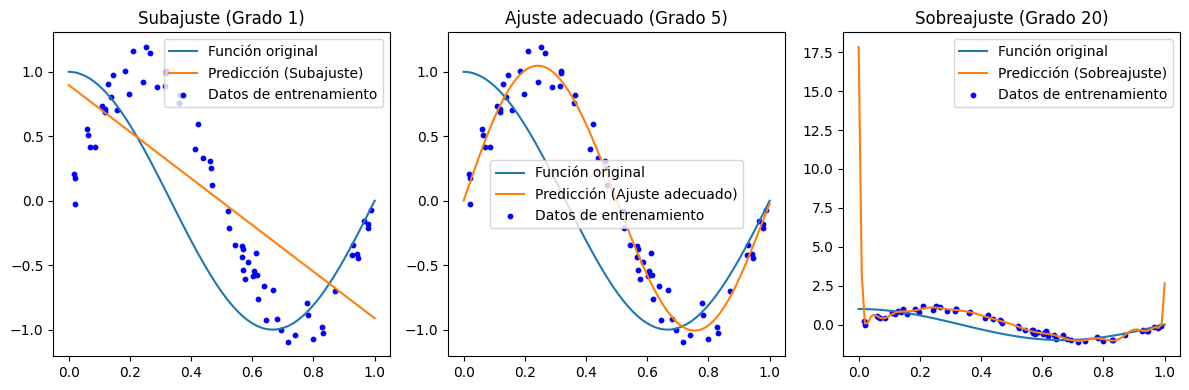

In [27]:
# prompt:  Grafica de manera separada para cada modelo, las predicciones que realiza sobre el conjunto de datos X_vis, el cual se encuentra definido en la tercera celda. Compare visualmente estas predicciones con la forma de la función sinusoidal original y comente los resultados.

# Entrena los modelos con los grados seleccionados
poly_features_subajuste = PolynomialFeatures(degree=grado_subajuste)
X_train_poly_subajuste = poly_features_subajuste.fit_transform(X_train)
X_vis_poly_subajuste = poly_features_subajuste.transform(X_vis.reshape(-1, 1))
model_subajuste = LinearRegression()
model_subajuste.fit(X_train_poly_subajuste, y_train)
y_vis_pred_subajuste = model_subajuste.predict(X_vis_poly_subajuste)


poly_features_ajuste_adecuado = PolynomialFeatures(degree=grado_ajuste_adecuado)
X_train_poly_ajuste_adecuado = poly_features_ajuste_adecuado.fit_transform(X_train)
X_vis_poly_ajuste_adecuado = poly_features_ajuste_adecuado.transform(X_vis.reshape(-1, 1))
model_ajuste_adecuado = LinearRegression()
model_ajuste_adecuado.fit(X_train_poly_ajuste_adecuado, y_train)
y_vis_pred_ajuste_adecuado = model_ajuste_adecuado.predict(X_vis_poly_ajuste_adecuado)


poly_features_sobreajuste = PolynomialFeatures(degree=grado_sobrecarga)
X_train_poly_sobreajuste = poly_features_sobreajuste.fit_transform(X_train)
X_vis_poly_sobreajuste = poly_features_sobreajuste.transform(X_vis.reshape(-1, 1))
model_sobreajuste = LinearRegression()
model_sobreajuste.fit(X_train_poly_sobreajuste, y_train)
y_vis_pred_sobreajuste = model_sobreajuste.predict(X_vis_poly_sobreajuste)


# Graficar las predicciones para cada modelo

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(X_vis, true_fun(X_vis), label='Función original')
plt.plot(X_vis, y_vis_pred_subajuste, label='Predicción (Subajuste)')
plt.scatter(X_train, y_train, color='blue', s=10, label='Datos de entrenamiento')
plt.title('Subajuste (Grado ' + str(grado_subajuste) + ')')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(X_vis, true_fun(X_vis), label='Función original')
plt.plot(X_vis, y_vis_pred_ajuste_adecuado, label='Predicción (Ajuste adecuado)')
plt.scatter(X_train, y_train, color='blue', s=10, label='Datos de entrenamiento')
plt.title('Ajuste adecuado (Grado ' + str(grado_ajuste_adecuado) + ')')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(X_vis, true_fun(X_vis), label='Función original')
plt.plot(X_vis, y_vis_pred_sobreajuste, label='Predicción (Sobreajuste)')
plt.scatter(X_train, y_train, color='blue', s=10, label='Datos de entrenamiento')
plt.title('Sobreajuste (Grado ' + str(grado_sobrecarga) + ')')
plt.legend()

plt.tight_layout()
plt.show()

#Comentarios:
#El modelo con subajuste no logra capturar la complejidad de la función sinusoidal, generando una aproximación lineal muy simple que no se ajusta adecuadamente a los datos.
#El modelo con ajuste adecuado logra una aproximación bastante precisa a la forma de la función sinusoidal, capturando su comportamiento general y minimizando la desviación.
#El modelo con sobreajuste, debido a su complejidad excesiva, se adapta demasiado a los datos de entrenamiento, incluso al ruido. Esto provoca que la predicción sea muy irregular y fluctúe demasiado, lo que la aleja de la función original.